# 05 — Advanced path: temporal holdout evaluation + hybrid CLV / churn proxies

## Why this notebook exists

Silhouette answers: *do points form blobs?*  
Marketing answers: *do segments differ on **future** spend and return?*

Here we:

1. Cut time into **history** (features only ≤ cutoff) and **future** (next 90 days)  
2. Cluster with **baseline RFM** vs **RFM+** on history (no leakage)  
3. Score each segment on **future monetary**, **retention**, and **lift**  
4. Fit simple **CLV / retention proxies** and build **hybrid** labels (cluster + value band)

Baseline notebooks 01–03 are **not** modified.

In [1]:
from __future__ import annotations

import random
import sys
import warnings
from pathlib import Path

import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from segmentation.advanced.features_plus import (
    RFM_BASIC_COLS,
    RFM_PLUS_CLUSTER_COLS,
    load_retail_transactions,
)
from segmentation.advanced.hybrid import fit_clv_proxy, hybrid_segment_table
from segmentation.advanced.temporal import (
    build_customer_features_asof,
    evaluate_future_outcomes,
    future_outcomes,
    separation_score,
    time_split_cutoff,
)
from segmentation.advanced.whales import split_whales
from segmentation.metrics import internal_metrics
from segmentation.preprocess import prepare_matrix

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

## 1. Data + time cutoff (anti-leakage)

Features for customer *i* use only invoices with `date ≤ cutoff`.  
Outcomes use invoices in `(cutoff, cutoff+90d]`.

In [2]:
tx, meta = load_retail_transactions(ROOT, prefer="ii")
print(meta)
cutoff = time_split_cutoff(tx, train_frac=0.75)  # keyword-only style
horizon = 90
print("Cutoff (as-of):", cutoff)
print("Future window: (", cutoff, ",", cutoff + pd.Timedelta(days=horizon), "]")

hist_feat = build_customer_features_asof(tx, cutoff)
print("Customers with history features:", len(hist_feat))
# need some purchase history
hist_feat = hist_feat.loc[hist_feat["Frequency"] >= 1].copy()
core, whales, thr = split_whales(hist_feat, upper_q=0.99)
print(f"Core={len(core)} whales={len(whales)} thr={thr:.2f}")

{'dataset': 'ii', 'source': "UCI 502 xlsx sheets=['Year 2009-2010', 'Year 2010-2011']", 'colmap': {'invoice': 'Invoice', 'customer': 'Customer ID', 'qty': 'Quantity', 'price': 'Price', 'date': 'InvoiceDate', 'stock': 'StockCode', 'country': 'Country'}, 'n_raw': 1067371}
Cutoff (as-of): 2011-06-07 07:45:00
Future window: ( 2011-06-07 07:45:00 , 2011-09-05 07:45:00 ]


Customers with history features: 4956
Core=4906 whales=50 thr=25611.47


## 2. Cluster on history only — baseline RFM vs RFM+

In [3]:
def cluster_core(df, cols, k=None):
    log_cols = [c for c in cols if any(x in c for x in [
        "Frequency", "Monetary", "AvgOrder", "StdOrder", "NUnique", "FreqLast", "Stock"
    ])]
    X, _, _, _ = prepare_matrix(df, cols, winsorize=True, log_cols=log_cols, scaler="robust")
    if k is None:
        best_k, best_sil, best_lab = 4, -1, None
        for kk in range(2, 7):
            lab = KMeans(kk, random_state=SEED, n_init=25, max_iter=400).fit_predict(X)
            sil = internal_metrics(X, lab)["silhouette"]
            if sil > best_sil:
                best_k, best_sil, best_lab = kk, sil, lab
        k, labels = best_k, best_lab
    else:
        labels = KMeans(k, random_state=SEED, n_init=25, max_iter=400).fit_predict(X)
    m = internal_metrics(X, labels)
    m["k"] = k
    return labels, m, X

cols_b = [c for c in RFM_BASIC_COLS if c in core.columns]
cols_p = [c for c in RFM_PLUS_CLUSTER_COLS if c in core.columns]
lab_b, met_b, Xb = cluster_core(core, cols_b)
lab_p, met_p, Xp = cluster_core(core, cols_p)

print("Baseline RFM history metrics:", met_b)
print("RFM+ history metrics:", met_p)

Baseline RFM history metrics: {'n_clusters': 2, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': 55.197717081125155, 'min_cluster_pct': 44.802282918874845, 'silhouette': 0.41112698773269835, 'davies_bouldin': 0.9014188968502156, 'calinski_harabasz': 4826.903841792646, 'k': 2}
RFM+ history metrics: {'n_clusters': 2, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': 88.25927435792907, 'min_cluster_pct': 11.740725642070933, 'silhouette': 0.44919834305066075, 'davies_bouldin': 0.9593925395569506, 'calinski_harabasz': 1911.3470345743478, 'k': 2}


## 3. Future outcomes by segment (the “is it awesome?” test)

=== Future metrics — baseline RFM segments ===


,segment,n,mean_future_monetary,median_future_monetary,total_future_monetary,retention_rate,mean_future_orders,lift_future_monetary,lift_retention,pct_customers,pct_future_value
1,1,2198,425.053999,114.545,934268.69,0.528207,1.140582,1.930451,1.651616,44.802283,86.488608
0,0,2708,53.896968,0.000,145952.99,0.150665,0.202733,0.244782,0.471103,55.197717,13.511392


separation {'future_value_ratio_max_min': 7.886417602927778, 'retention_gap': 0.37754276413497967, 'top_segment_future_value_share': 86.48860759765532}

=== Future metrics — RFM+ segments ===


,segment,n,mean_future_monetary,median_future_monetary,total_future_monetary,retention_rate,mean_future_orders,lift_future_monetary,lift_retention,pct_customers,pct_future_value
0,0,576,640.890521,355.81,369152.94,0.640625,1.581597,2.910707,2.003127,11.740726,34.173813
1,1,4330,164.219109,0.00,711068.74,0.277136,0.495381,0.745827,0.866559,88.259274,65.826187


separation {'future_value_ratio_max_min': 3.9026549742692014, 'retention_gap': 0.36348874133949194, 'top_segment_future_value_share': 34.173813286176596}


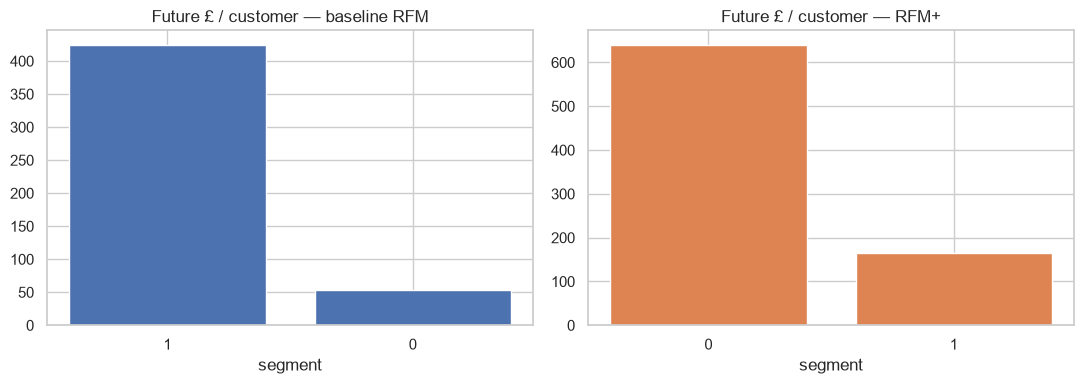

In [4]:
sum_b = evaluate_future_outcomes(core, lab_b, tx, cutoff=cutoff, horizon_days=horizon)
sum_p = evaluate_future_outcomes(core, lab_p, tx, cutoff=cutoff, horizon_days=horizon)
print("=== Future metrics — baseline RFM segments ===")
display(sum_b)
print("separation", separation_score(sum_b))
print("\n=== Future metrics — RFM+ segments ===")
display(sum_p)
print("separation", separation_score(sum_p))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(sum_b["segment"].astype(str), sum_b["mean_future_monetary"], color="C0")
axes[0].set_title("Future £ / customer — baseline RFM")
axes[0].set_xlabel("segment")
axes[1].bar(sum_p["segment"].astype(str), sum_p["mean_future_monetary"], color="C1")
axes[1].set_title("Future £ / customer — RFM+")
axes[1].set_xlabel("segment")
plt.tight_layout()
plt.show()

## 4. How to read the lift numbers

- **`lift_future_monetary` > 1** → segment spends more next 90d than portfolio average  
- **`retention_rate`** → fraction with ≥1 order in the future window  
- **`future_value_ratio_max_min`** → how many times richer the top segment is vs the bottom  

If RFM+ increases that ratio or top-segment future value share, the **feature upgrade
is working for business**, even when Silhouette only moves a little.

In [5]:
sep_b, sep_p = separation_score(sum_b), separation_score(sum_p)
cmp = pd.DataFrame([
    {"pipeline": "baseline_RFM", **met_b, **sep_b,
     "top_seg_future_share": sum_b["pct_future_value"].iloc[0]},
    {"pipeline": "RFM_plus", **met_p, **sep_p,
     "top_seg_future_share": sum_p["pct_future_value"].iloc[0]},
])
print("Head-to-head (history geometry + future separation):")
display(cmp)

Head-to-head (history geometry + future separation):


,pipeline,n_clusters,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,k,future_value_ratio_max_min,retention_gap,top_segment_future_value_share,top_seg_future_share
0,baseline_RFM,2,0,0.0,55.197717,44.802283,0.411127,0.901419,4826.903842,2,7.886418,0.377543,86.488608,86.488608
1,RFM_plus,2,0,0.0,88.259274,11.740726,0.449198,0.959393,1911.347035,2,3.902655,0.363489,34.173813,34.173813


## 5. Hybrid CLV / retention proxies

Unsupervised clusters group *similar histories*.  
Supervised proxies rank *expected future value*.  
**Hybrid** = cluster id + predicted value band → finer CRM targeting without
pretending clusters have ground-truth labels.

In [6]:
outcomes = future_outcomes(tx, core["customer_id"], cutoff=cutoff, horizon_days=horizon)
y_m = core.merge(outcomes, on="customer_id", how="left")["future_monetary"].fillna(0).to_numpy()
y_r = core.merge(outcomes, on="customer_id", how="left")["retained"].fillna(0).to_numpy().astype(int)

proxy = fit_clv_proxy(Xp, y_m, y_r, seed=SEED)
print("Holdout R² (future monetary):", proxy["holdout_r2_future_monetary"])
print("Holdout AUC (retention):", proxy["holdout_auc_retention"])

pred_m = proxy["regressor"].predict(Xp)
pred_r = (
    proxy["classifier"].predict_proba(Xp)[:, 1]
    if proxy["classifier"] is not None
    else np.full(len(Xp), np.nan)
)
hybrid = hybrid_segment_table(core, lab_p, pred_m, pred_r)
display(hybrid.head(10))
print("Hybrid segment counts:")
display(hybrid["hybrid_segment"].value_counts().head(15))

# hybrid future quality: group by hybrid label
core_h = core.copy()
core_h["hybrid_segment"] = hybrid["hybrid_segment"].values
# map hybrid to evaluate — use string labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
hy_codes = le.fit_transform(hybrid["hybrid_segment"])
sum_h = evaluate_future_outcomes(core, hy_codes, tx, cutoff=cutoff, horizon_days=horizon)
sum_h["hybrid_name"] = sum_h["segment"].map(lambda i: le.inverse_transform([int(i)])[0])
print("Top hybrid segments by future monetary:")
display(sum_h.head(8))
print("Hybrid separation", separation_score(sum_h))

Holdout R² (future monetary): 0.3926144118284818
Holdout AUC (retention): 0.8224709784411277


,customer_id,cluster,pred_future_monetary,pred_retention,value_band,hybrid_segment
1,12347.0,1,582.012359,0.766811,V2,1|V2
2,12348.0,1,261.835623,0.471287,V2,1|V2
3,12349.0,1,329.845109,0.282656,V2,1|V2
4,12350.0,1,94.206315,0.180727,V1,1|V1
5,12351.0,1,32.921668,0.125390,V0,1|V0
6,12352.0,1,281.056422,0.466995,V2,1|V2
7,12353.0,1,57.458736,0.165341,V1,1|V1
8,12354.0,0,302.926020,0.434871,V2,0|V2
9,12355.0,0,188.067761,0.131201,V2,0|V2
10,12356.0,1,858.706677,0.634596,V2,1|V2


Hybrid segment counts:


hybrid_segment
1|V0    1635
1|V1    1618
1|V2    1077
0|V2     558
0|V1      17
0|V0       1
Name: count, dtype: int64

Top hybrid segments by future monetary:


,segment,n,mean_future_monetary,median_future_monetary,total_future_monetary,retention_rate,mean_future_orders,lift_future_monetary,lift_retention,pct_customers,pct_future_value,hybrid_name
2,2,558,657.877419,362.825,367095.60,0.652330,1.620072,2.987856,2.039726,11.373828,33.983358,0|V2
5,5,1077,518.543742,300.100,558471.61,0.605385,1.328691,2.355050,1.892938,21.952711,51.699722,1|V2
1,1,17,121.020000,0.000,2057.34,0.294118,0.411765,0.549632,0.919657,0.346514,0.190455,0|V1
4,4,1618,71.920439,0.000,116367.27,0.250927,0.334363,0.326638,0.784607,32.980024,10.772536,1|V1
3,3,1635,22.158936,0.000,36229.86,0.086850,0.105810,0.100638,0.271566,33.326539,3.353928,1|V0
0,0,1,0.000000,0.000,0.00,0.000000,0.000000,0.000000,0.000000,0.020383,0.000000,0|V0


Hybrid separation {'future_value_ratio_max_min': 657.8774193548387, 'retention_gap': 0.6523297491039427, 'top_segment_future_value_share': 33.98335793445656}


## 6. Takeaways

| Question | Where answered |
|----------|----------------|
| Did we leak future into features? | No — as-of cutoff |
| Are segments useful commercially? | Future £ and retention tables |
| Did RFM+ help vs baseline RFM? | Head-to-head comparison frame |
| How do we target inside a cluster? | Hybrid `cluster|Vband` |

Next (**06**): soft GMM membership, hierarchical VIP→core, rolling stability, scoring API + playbooks.

In [7]:
print("DONE notebook 05")
print(cmp.to_string(index=False))

DONE notebook 05
    pipeline  n_clusters  n_noise  noise_pct  largest_cluster_pct  min_cluster_pct  silhouette  davies_bouldin  calinski_harabasz  k  future_value_ratio_max_min  retention_gap  top_segment_future_value_share  top_seg_future_share
baseline_RFM           2        0        0.0            55.197717        44.802283    0.411127        0.901419        4826.903842  2                    7.886418       0.377543                       86.488608             86.488608
    RFM_plus           2        0        0.0            88.259274        11.740726    0.449198        0.959393        1911.347035  2                    3.902655       0.363489                       34.173813             34.173813
